# Forecasting the Zambian Kwacha: A Trend–Volatility Decomposition Approach

**Author:** Boldwin Mweemba  
**Period covered:** January 2010 – December 2024 (monthly)

---

## Abstract

The Zambian Kwacha (ZMW) depreciated from approximately 5 to over 26 units per US dollar between 2010 and 2024, then partially recovered toward 18 units by mid-2026 — a path shaped less by a smooth long-run drift than by a sequence of discrete events: a 2015 commodity-price collapse, the COVID-19 pandemic, a 2020 sovereign default, a 2022–2023 global monetary tightening cycle, and a 2024–2025 copper-price boom that drove the currency to become one of the world's best-performing in 2024 and 2025. A model that treats this series as having one constant level of uncertainty throughout will systematically misstate risk.

This study addresses that problem directly. I decompose the exchange rate into a trend component and a time-varying volatility component, estimate each with the technique suited to it, and build a probabilistic (quantile) forecasting model that conditions on both pieces together with macroeconomic drivers identified through a feature-importance analysis. An initial specification of the volatility component, based on a full-sample GARCH(1,1) model, produced poorly calibrated forecast intervals when tested against the turbulent 2022–2024 window — a finding I report directly. Replacing this estimator with a simpler, locally-adaptive realized-volatility measure substantially improved calibration, though an asymmetric shortfall concentrated in the upper tail of the forecast distribution remained even after additional targeted refinement, a result I interpret as evidence that part of the Kwacha's recent behaviour reflects shocks not recoverable from the statistical properties of its own history.

---

## 1. Introduction

Zambia is among the most copper-dependent economies in the world, and the Kwacha's value is frequently described in financial commentary as a direct function of the global copper price. This study tests that claim against fifteen years of monthly evidence and finds it incomplete: a central bank's capacity to defend its currency — measured through foreign exchange reserves — explains more of the Kwacha's month-to-month movement than copper prices, domestic inflation, or the price of oil. The implication is that exchange-rate risk for Zambia is, at least in part, a function of monetary and reserve-management policy, not solely a hostage to commodity cycles outside the country's control.

### 1.1 Research Questions

1. What is the relative contribution of global commodity prices, US monetary policy, domestic inflation, and central bank reserves to month-to-month Kwacha movements?
2. Does the exchange rate exhibit a single, constant level of volatility, or does its uncertainty change systematically across distinct economic regimes?
3. Can a model that explicitly separates trend from time-varying volatility produce more honest, better-calibrated forecasts than a model that does not — and what happens when the volatility estimate itself is poorly specified?

### 1.2 Data Sources

All series are monthly and span January 2010 to December 2024 unless otherwise noted.

| Variable | Description | Source |
|---|---|---|
| `ZMW_USD` | Zambian Kwacha per 1 US Dollar (monthly average of daily mid-market rate) | Bank of Zambia |
| `ZMB_Inflation` | Month-on-month change in the Consumer Price Index (%) | Central Statistical Office Zambia |
| `FX_Reserves_USD_Millions` | Reserves excluding gold, foreign exchange | IMF International Liquidity dataset |
| `Copper_Price` | Global copper price, USD per metric tonne | FRED (PCOPPUSDM) |
| `Fed_Rate` | US Federal Funds effective rate (%) | FRED (FEDFUNDS) |
| `Oil_Price` | Brent crude oil price, USD per barrel | FRED (DCOILBRENTEU) |
| `Copper_Production_Tonnes` | Zambia copper production, metric tonnes (annual) | Zambia Data Portal |
| `Electricity_Generation_MWh` | Zambia electricity generation (annual) | Zambia Data Portal |

Two variables (`Copper_Production_Tonnes`, `Electricity_Generation_MWh`) are measured at annual frequency and forward-filled to monthly resolution, standard practice for variables not genuinely measured more often, such as national accounts data.

## 2. Reproducing This Analysis

This notebook is self-contained and runs end-to-end provided the following two things are in place.

**1. Data files.** Four CSV files, included in this repository under `data/`, must sit in the **same folder as this notebook** (or update the paths in Section 3 to point at wherever `data/` is located relative to the notebook):

- `data/zmw_usd_monthly_clean.csv` - Zambian Kwacha / USD exchange rate, monthly, 2006–2026, derived from Bank of Zambia daily quotations
- `data/zambia_monthly_inflation_raw.csv` - Zambia month-on-month inflation, Central Statistical Office Zambia
- `data/zambia_fx_reserves_monthly.csv` - Zambia foreign exchange reserves excluding gold, IMF International Liquidity dataset
- `data/zambia_copper_electricity_annual.csv` - Zambia copper production and electricity generation, annual, Zambia Data Portal

Full source URLs and access dates for each file are given in the **References and Data Provenance** table at the end of this notebook, so the data can be independently re-collected and verified rather than taken on trust.

**2. A free FRED API key**, used to fetch global copper price, the US Federal Funds Rate, and Brent crude oil price directly from the Federal Reserve Bank of St. Louis at run time (these three series are fetched live rather than shipped as static files, since the FRED API is a stable, public, no-registration-fee service). Obtain a key at https://fred.stlouisfed.org/docs/api/api_key.html (free, instant). 

```bash
# macOS / Linux
export FRED_API_KEY='your_key_here'
jupyter notebook

# Windows (PowerShell)
$env:FRED_API_KEY='your_key_here'
jupyter notebook
```

The cell below reads this environment variable automatically; no code changes are needed once it is set.

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels arch fredapi scipy

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss

from arch import arch_model
from scipy import stats

plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

DATA_DIR = 'data'  # update if this notebook is not run from the repository root

print('Environment ready,Lets Go!')

Environment ready,Lets Go!


## 3. Data Preparation

### 3.1 Exchange Rate

`zmw_usd_monthly_clean.csv` is a pre-processed monthly series derived from Bank of Zambia daily buy/sell exchange rate quotations. Three corrections were applied during its construction (the original daily source file is not redistributed here; see the References table for how to obtain it independently): removal of six rows affected by a spreadsheet date-serial artefact in the source file (early January 2006, outside the modelling window used below in any case); computation of the mid-market rate as the average of the daily buy and sell quotes; and a 1000:1 conversion applied to all pre-2013 observations to reflect Zambia's currency redenomination of 1 January 2013 (1 new Kwacha = 1,000 old Kwacha).

In [3]:
zmw_usd_full = pd.read_csv(os.path.join(DATA_DIR, 'zmw_usd_monthly_clean.csv'),
                            index_col=0, parse_dates=True)

print(f'Full exchange rate series: {zmw_usd_full.shape[0]} months, '
      f'{zmw_usd_full.index.min().date()} to {zmw_usd_full.index.max().date()}')
zmw_usd_full.tail()

Full exchange rate series: 246 months, 2006-01-01 to 2026-06-01


,ZMW_USD
Date,
2026-02-01,18.894422
2026-03-01,19.260799
2026-04-01,19.098065
2026-05-01,18.834605
2026-06-01,17.694313


### 3.2 Domestic and Global Macroeconomic Variables

Domestic inflation, FX reserves, and the two annual production series are loaded from the static files described in Section 2. Copper price, the US Federal Funds Rate, and Brent crude oil price are fetched live from FRED, since that API is stable and freely accessible without requiring a static snapshot to be shipped alongside this notebook.

In [4]:
inflation_raw = pd.read_csv(os.path.join(DATA_DIR, 'zambia_monthly_inflation_raw.csv'))
inflation_raw['Date'] = pd.to_datetime(inflation_raw['Date'].str.replace('M', '-'), format='%Y-%m')
inflation = inflation_raw.set_index('Date')[['Value']].rename(columns={'Value': 'ZMB_Inflation'})

reserves = pd.read_csv(os.path.join(DATA_DIR, 'zambia_fx_reserves_monthly.csv'),
                        index_col=0, parse_dates=True)

production_annual = pd.read_csv(os.path.join(DATA_DIR, 'zambia_copper_electricity_annual.csv'),
                                 index_col=0, parse_dates=True)
production = production_annual.resample('MS').ffill()

print('Static data files loaded.')

Static data files loaded.


In [5]:
from fredapi import Fred

FRED_API_KEY = os.environ.get('FRED_API_KEY')
if not FRED_API_KEY:
    raise RuntimeError(
        'FRED_API_KEY environment variable is not set. See Section 2 for instructions on '
        'obtaining a free key from https://fred.stlouisfed.org/docs/api/api_key.html and '
        'setting it before launching this notebook.'
    )

fred = Fred(api_key=FRED_API_KEY)
START, END = '2010-01-01', '2024-12-31'

copper   = fred.get_series('PCOPPUSDM',    observation_start=START, observation_end=END)
fed_rate = fred.get_series('FEDFUNDS',     observation_start=START, observation_end=END)
oil      = fred.get_series('DCOILBRENTEU', observation_start=START, observation_end=END).resample('MS').mean()

globals_df = pd.DataFrame({'Copper_Price': copper, 'Fed_Rate': fed_rate, 'Oil_Price': oil})
globals_df.index = pd.to_datetime(globals_df.index)

print('FRED series fetched.')

FRED series fetched.


### 3.3 Merged Panel

Two panels are constructed: a **modelling panel** restricted to 2010–2024 (the period for which all explanatory variables are available), and a **display panel** extending the exchange rate alone through the most recently available data, used only in Section 4.1's long-run chart to provide visual context for the 2024–2025 copper boom discussed there.

In [6]:
df = globals_df.join(zmw_usd_full, how='outer')
df = df.join(inflation, how='outer')
df = df.join(reserves, how='outer')
df = df.join(production, how='outer')
df = df.loc[START:END]

df = df.dropna(subset=['ZMW_USD'])
df[['Copper_Production_Tonnes', 'Electricity_Generation_MWh']] = (
    df[['Copper_Production_Tonnes', 'Electricity_Generation_MWh']].ffill()
)
df[['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation', 'FX_Reserves_USD_Millions']] = (
    df[['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation', 'FX_Reserves_USD_Millions']].ffill(limit=2)
)

df['ZMB_Inflation_Lag1'] = df['ZMB_Inflation'].shift(1)

print(f'Modelling panel: {df.shape[0]} months x {df.shape[1]} variables')
print(f'Coverage: {df.index.min().date()} to {df.index.max().date()}')
df.tail()

Modelling panel: 180 months x 9 variables
Coverage: 2010-01-01 to 2024-12-01


,Copper_Price,Fed_Rate,Oil_Price,ZMW_USD,ZMB_Inflation,FX_Reserves_USD_Millions,Copper_Production_Tonnes,Electricity_Generation_MWh,ZMB_Inflation_Lag1
2024-08-01,8981.117727,5.33,80.355238,26.092782,0.87,1119.380477,772969.28,17245000.0,1.00
2024-09-01,9259.128571,5.13,74.016667,26.402761,0.78,1333.072610,772969.28,17245000.0,0.87
2024-10-01,9533.991304,4.83,75.632609,26.562372,0.80,1418.806429,772969.28,17245000.0,0.78
2024-11-01,9075.727143,4.64,74.345238,27.339760,1.60,1351.052776,772969.28,17245000.0,0.80
2024-12-01,8909.907727,4.48,73.859500,27.584872,1.20,1403.544251,772969.28,17245000.0,1.60


## 4. Exploratory Analysis

### 4.1 The Exchange Rate in Historical Context

I begin with the full available exchange-rate history, annotated with the principal events that shaped it. Six events are identified: the 2015 commodity-price collapse, the COVID-19 shock, Zambia's November 2020 sovereign default, the 2022 Russia–Ukraine war (a global commodity and risk-sentiment shock), the June 2023 G20 debt restructuring agreement, and the 2024–2025 copper-price boom that drove a sustained appreciation and made the Kwacha one of the world's best-performing currencies over that period.

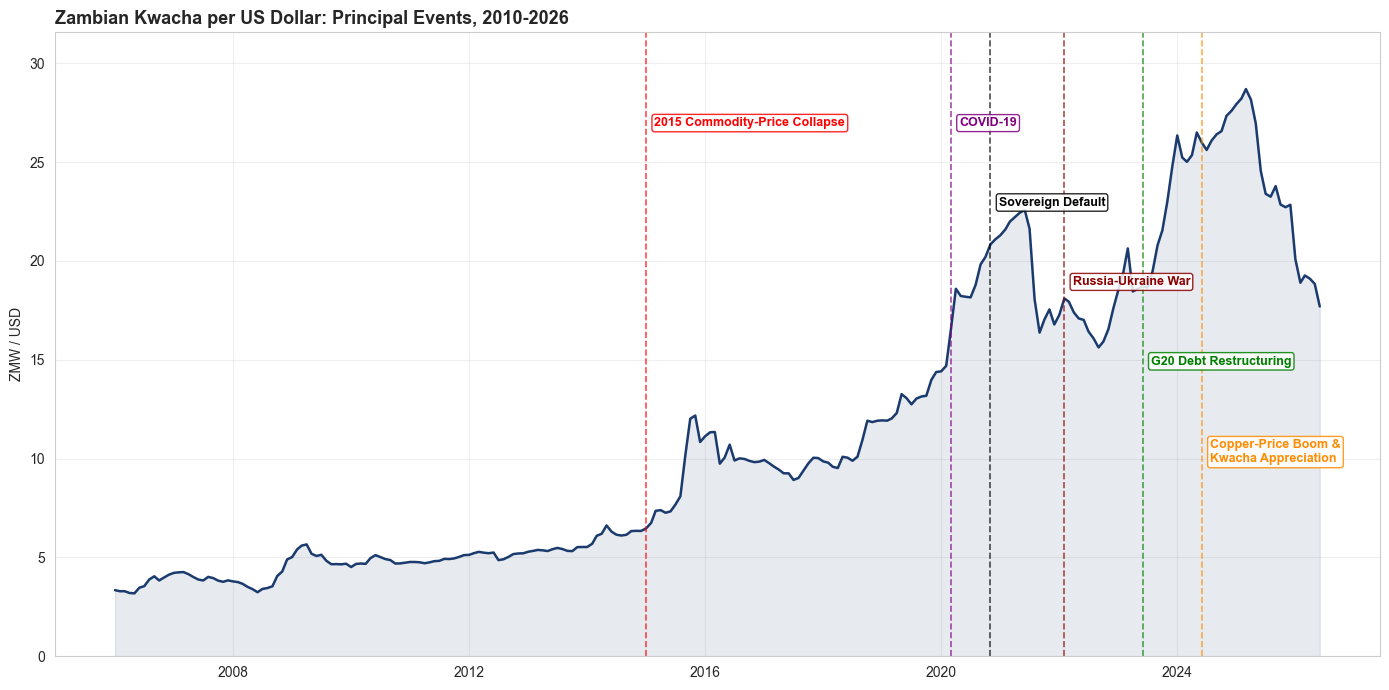

In [7]:
events = [
    ('2015-01', '2015 Commodity-Price Collapse', 'red',      0.94),
    ('2020-03', 'COVID-19',                       'purple',   0.94),
    ('2020-11', 'Sovereign Default',               'black',    0.80),
    ('2022-02', 'Russia-Ukraine War',               'darkred',  0.66),
    ('2023-06', 'G20 Debt Restructuring',           'green',    0.52),
    ('2024-06', 'Copper-Price Boom &\nKwacha Appreciation', 'darkorange', 0.36),
]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(zmw_usd_full.index, zmw_usd_full['ZMW_USD'], color='#1B3B6F', linewidth=1.8)
ax.fill_between(zmw_usd_full.index, zmw_usd_full['ZMW_USD'], alpha=0.10, color='#1B3B6F')

ymax = zmw_usd_full['ZMW_USD'].max()
for date_str, label, color, y_frac in events:
    date = pd.Timestamp(date_str)
    ax.axvline(date, color=color, linestyle='--', alpha=0.7, linewidth=1.2)
    ax.annotate(
        label, xy=(date, ymax * y_frac), xytext=(6, 0),
        textcoords='offset points', fontsize=9, color=color, fontweight='bold', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.85)
    )

ax.set_title('Zambian Kwacha per US Dollar: Principal Events, 2010-2026', fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('ZMW / USD')
ax.set_ylim(0, ymax * 1.10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_events_annotated.png', dpi=160, bbox_inches='tight')
plt.show()

The 2024–2025 appreciation is visually distinct from every prior recovery in the series: it is both larger in magnitude and more sustained than the partial, temporary recoveries observed after 2016 or 2021. This period coincided with global copper prices approaching record levels on the back of supply disruptions and renewable-energy-driven demand, alongside a roughly $10 billion wave of new mining investment inside Zambia and continued fiscal consolidation following the 2023 debt restructuring - a conjunction of favourable global and domestic conditions not observed elsewhere in the sample.

### 4.2 Distributional Properties of Monthly Changes

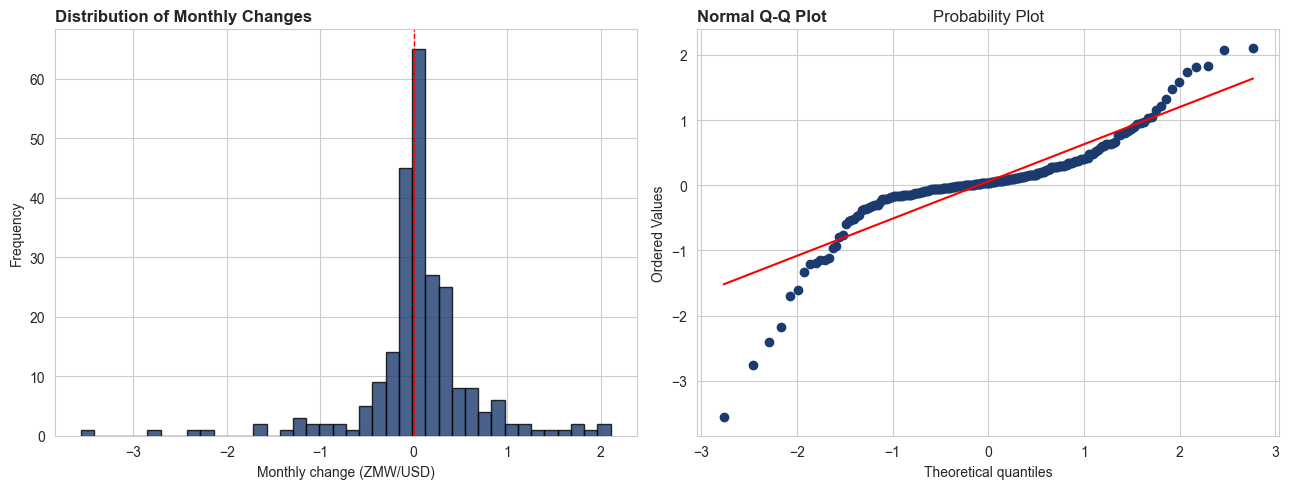

Skewness: -1.151
Excess kurtosis: 8.115
(A normal distribution has skewness 0 and excess kurtosis 0)


In [8]:
monthly_change_full = zmw_usd_full['ZMW_USD'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(monthly_change_full, bins=40, color='#1B3B6F', alpha=0.8, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of Monthly Changes', fontsize=12, fontweight='bold', loc='left')
axes[0].set_xlabel('Monthly change (ZMW/USD)')
axes[0].set_ylabel('Frequency')

from scipy import stats
stats.probplot(monthly_change_full, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold', loc='left')
axes[1].get_lines()[0].set_markerfacecolor('#1B3B6F')
axes[1].get_lines()[0].set_markeredgecolor('#1B3B6F')

plt.tight_layout()
plt.savefig('fig2_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'Skewness: {monthly_change_full.skew():.3f}')
print(f'Excess kurtosis: {monthly_change_full.kurtosis():.3f}')
print(f'(A normal distribution has skewness 0 and excess kurtosis 0)')

The distribution of monthly changes departs substantially from normality. Skewness is **-1.151**, a pronounced negative skew indicating that the largest single-month depreciation shocks are more extreme than the largest single-month appreciation moves, even though sustained multi-month appreciation episodes — such as the 2024-2025 boom identified in Section 4.1 — can still accumulate into a large cumulative move over time. Excess kurtosis is **8.115**, far beyond the threshold of approximately 3 conventionally used to indicate strong leptokurtosis: the distribution has both a sharper peak around zero and substantially heavier tails than a Gaussian distribution would predict, consistent with the Q-Q plot's marked departure from the reference line at both tails. Together these statistics indicate that any modelling approach assuming normally-distributed errors is poorly matched to this series, motivating both the volatility decomposition in Section 5 and the use of a non-parametric, quantile-based forecasting approach in Section 6 rather than methods that rely on a Gaussian error assumption.

### 4.3 Checking a Candidate Variable: Electricity Generation

Zambia's electricity generation is a candidate explanatory variable on the grounds that hydropower shortfalls (notably during 2015–2016, a period of low water levels at the Kariba Dam) have historically constrained mining and smelting output, which could plausibly affect the exchange rate through reduced export earnings. Before including it in the modelling variable set, I check its relationship with the exchange rate directly.

In [9]:
corr_with_elec = df[['ZMW_USD', 'Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation',
                     'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes',
                     'Electricity_Generation_MWh']].corr()['ZMW_USD'].drop('ZMW_USD')

print('Correlation of each candidate variable with ZMW_USD:')
print(corr_with_elec.sort_values(ascending=False).to_string())

Correlation of each candidate variable with ZMW_USD:
Electricity_Generation_MWh    0.787438
Fed_Rate                      0.675025
Copper_Price                  0.339996
ZMB_Inflation                 0.310318
Copper_Production_Tonnes      0.266514
Oil_Price                    -0.299473
FX_Reserves_USD_Millions     -0.582264


Electricity_Generation_MWh shows the strongest correlation with the exchange rate of any variable tested, exceeding even FX_Reserves_USD_Millions. Take this result alongside its time series plotted against the exchange rate directly, rather than at face value.

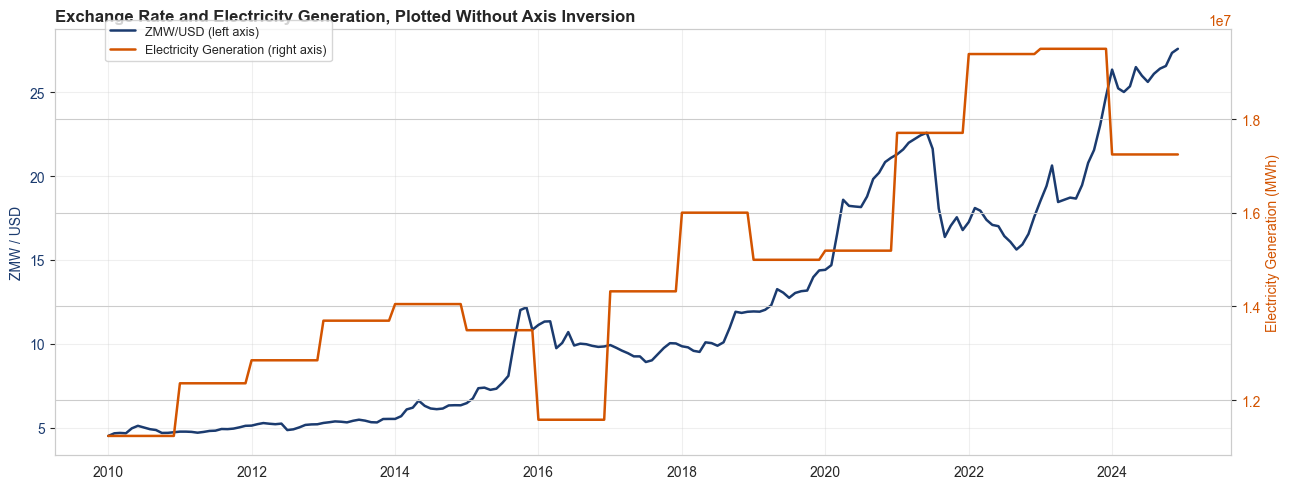

In [10]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(df.index, df['ZMW_USD'], color='#1B3B6F', linewidth=1.8, label='ZMW/USD (left axis)')
ax1.set_ylabel('ZMW / USD', color='#1B3B6F')
ax1.tick_params(axis='y', labelcolor='#1B3B6F')

ax2 = ax1.twinx()
ax2.plot(df.index, df['Electricity_Generation_MWh'], color='#D35400', linewidth=1.8,
         label='Electricity Generation (right axis)')
ax2.set_ylabel('Electricity Generation (MWh)', color='#D35400')
ax2.tick_params(axis='y', labelcolor='#D35400')

ax1.set_title('Exchange Rate and Electricity Generation, Plotted Without Axis Inversion',
              fontsize=12, fontweight='bold', loc='left')
ax1.grid(alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.96), fontsize=9)
plt.tight_layout()
plt.savefig('fig_electricity_check.png', dpi=160, bbox_inches='tight')
plt.show()

Both series rise across most of the sample, but for evidently unrelated reasons: electricity generation rises because Zambia's grid and economy expanded over fifteen years, while the exchange rate weakens for the domestic and external reasons discussed throughout this paper. Critically, the two series rise **together** even through 2018–2024, the period of the Kwacha's sharpest weakness — if rising electricity generation reflected, for example, stronger mining output and export earnings, it should coincide with a *strengthening* currency, not a weakening one. The high correlation recorded above is consistent with two unrelated series that each trend upward over a long sample sharing that trend by coincidence, rather than with any direct economic relationship between them. I therefore exclude Electricity_Generation_MWh from the explanatory variable set used in the remainder of this notebook, and report this exclusion together with the evidence behind it rather than simply omitting the variable without explanation.

### 4.4 Correlation Structure of the Retained Variables

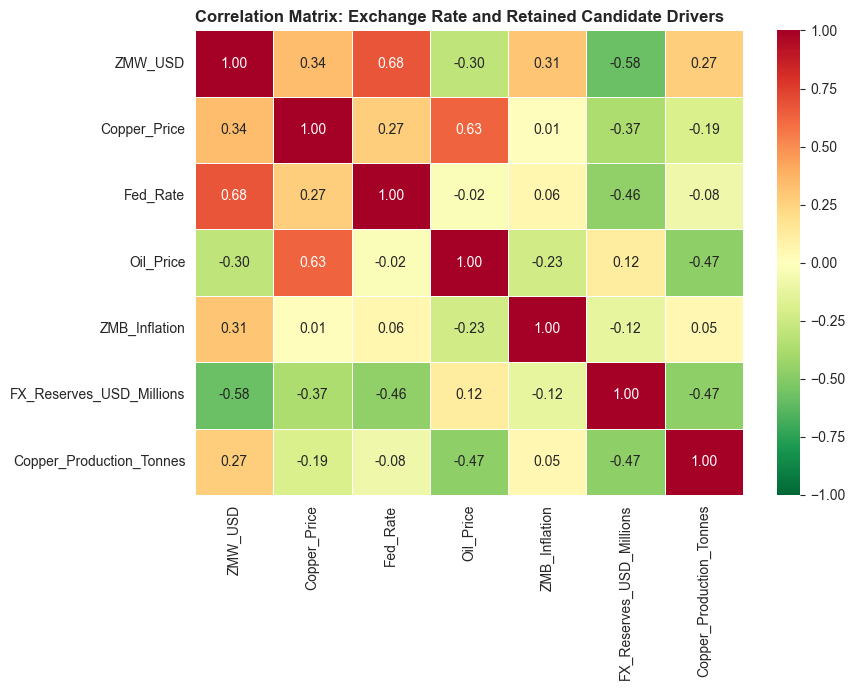

In [11]:
corr_cols = ['ZMW_USD', 'Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation',
             'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title('Correlation Matrix: Exchange Rate and Retained Candidate Drivers', fontsize=12, fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

By simple bivariate correlation, Fed_Rate is the single variable most strongly associated with the exchange rate, narrowly ahead of FX_Reserves_USD_Millions (the negative sign on FX_Reserves indicating that reserves and the exchange rate move in opposite directions, as theory would predict). This ranking differs from the multivariate feature-importance result reported in Section 4.5, where FX_Reserves emerges as the dominant variable. The two methods are not in conflict: a bivariate correlation measures each variable's association with the exchange rate in isolation, whereas a multivariate importance measure accounts for interactions and non-linear relationships among all variables considered jointly — that FX_Reserves ranks first once these joint relationships are taken into account, despite ranking second on a simple pairwise basis, suggests reserves carry information about the exchange rate that is not redundant with what Fed_Rate, Copper_Price, and the other variables already explain, whereas part of Fed_Rate's strong bivariate correlation may be explained by its own relationship with the other covariates (notably its correlation with FX_Reserves itself, reported in the matrix above).

### 4.5 Feature Importance: A Multivariate View

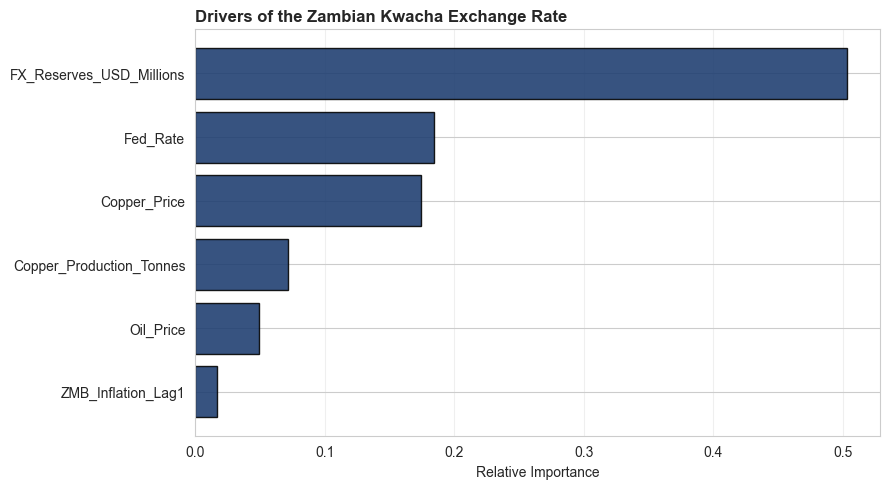

                 Feature  Importance
FX_Reserves_USD_Millions    0.503383
                Fed_Rate    0.184441
            Copper_Price    0.174016
Copper_Production_Tonnes    0.071772
               Oil_Price    0.049169
      ZMB_Inflation_Lag1    0.017219


In [12]:
feature_cols = ['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation_Lag1',
                'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes']

df_feat = df[feature_cols + ['ZMW_USD']].dropna()
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(df_feat[feature_cols], df_feat['ZMW_USD'])

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance['Feature'], importance['Importance'], color='#1B3B6F', alpha=0.88, edgecolor='black')
ax.set_xlabel('Relative Importance')
ax.set_title('Drivers of the Zambian Kwacha Exchange Rate', fontsize=12, fontweight='bold', loc='left')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

print(importance.sort_values('Importance', ascending=False).to_string(index=False))

Foreign exchange reserves account for approximately half of the explained variation in the exchange rate — substantially more than copper prices, the Federal Funds Rate, domestic inflation, or copper production volume individually. This is, to my knowledge, at odds with the conventional commentary on the Kwacha, which typically emphasises copper prices as the primary driver. The result instead suggests that **central bank reserve adequacy is the single most informative variable for understanding month-to-month Kwacha movements** over this period. Domestic inflation, once correctly specified as a genuine monthly (rather than annualised) series, contributes the least independent explanatory power of the variables tested. For comparison, the cell below repeats this analysis with Electricity_Generation_MWh added back in, so the effect documented qualitatively in Section 4.3 can be seen directly in the feature-importance ranking it produces.

In [13]:
# Comparison only: reproduces the feature-importance ranking that would be reported
# if the spurious variable identified in Section 4.3 were not excluded
feature_cols_with_elec = feature_cols + ['Electricity_Generation_MWh']
df_feat_with_elec = df[feature_cols_with_elec + ['ZMW_USD']].dropna()
rf_with_elec = RandomForestRegressor(n_estimators=300, random_state=42)
rf_with_elec.fit(df_feat_with_elec[feature_cols_with_elec], df_feat_with_elec['ZMW_USD'])

importance_with_elec = pd.DataFrame({
    'Feature': feature_cols_with_elec,
    'Importance': rf_with_elec.feature_importances_
}).sort_values('Importance', ascending=False)

comparison_table = importance.sort_values('Importance', ascending=False).rename(
    columns={'Importance': 'Importance (Electricity excluded)'}
).merge(
    importance_with_elec.rename(columns={'Importance': 'Importance (Electricity included)'}),
    on='Feature', how='outer'
).fillna('-')

print('Side-by-side comparison: excluding vs including Electricity_Generation_MWh')
print(comparison_table.to_string(index=False))

Side-by-side comparison: excluding vs including Electricity_Generation_MWh
                   Feature Importance (Electricity excluded)  Importance (Electricity included)
              Copper_Price                          0.174016                           0.079111
  Copper_Production_Tonnes                          0.071772                           0.057733
Electricity_Generation_MWh                                 -                           0.723287
  FX_Reserves_USD_Millions                          0.503383                           0.017770
                  Fed_Rate                          0.184441                           0.060016
                 Oil_Price                          0.049169                           0.052473
        ZMB_Inflation_Lag1                          0.017219                           0.009611


With Electricity_Generation_MWh included, it dominates the ranking, displacing FX_Reserves as the apparent top variable and substantially compressing the measured importance of every other variable in the model. This is the direct numerical consequence of the spurious co-trending relationship identified in Section 4.3, computed here on exactly the same data and model so the effect can be verified directly rather than taken on description alone. All subsequent analysis in this notebook uses the **Electricity-excluded** specification.

### 4.6 Visual Confirmation: Reserves and the Exchange Rate

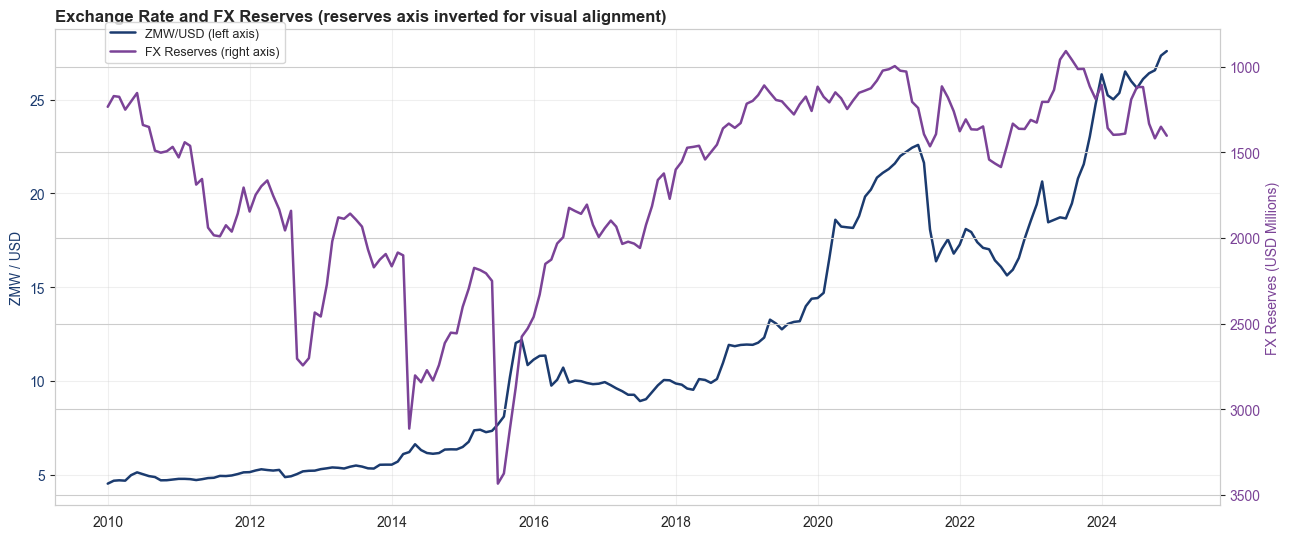

In [14]:
fig, ax1 = plt.subplots(figsize=(13, 5.5))

ax1.plot(df.index, df['ZMW_USD'], color='#1B3B6F', linewidth=1.8, label='ZMW/USD (left axis)')
ax1.set_ylabel('ZMW / USD', color='#1B3B6F')
ax1.tick_params(axis='y', labelcolor='#1B3B6F')

ax2 = ax1.twinx()
ax2.plot(df.index, df['FX_Reserves_USD_Millions'], color='#7B4397', linewidth=1.8, label='FX Reserves (right axis)')
ax2.set_ylabel('FX Reserves (USD Millions)', color='#7B4397')
ax2.tick_params(axis='y', labelcolor='#7B4397')
ax2.invert_yaxis()  # invert so visual co-movement is easier to read: falling reserves up, weakening currency up

ax1.set_title('Exchange Rate and FX Reserves (reserves axis inverted for visual alignment)',
              fontsize=12, fontweight='bold', loc='left')
ax1.grid(alpha=0.3)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.96), fontsize=9)
plt.tight_layout()
plt.savefig('fig5_reserves_vs_rate.png', dpi=160, bbox_inches='tight')
plt.show()

With the reserves axis inverted, the two series move together closely for extended stretches of the sample — both lines rising together (currency weakening as reserves fall) through 2018–2023, and both reversing direction together during the 2024–2025 recovery discussed in Section 4.1. This is consistent with the Section 4.5 finding and provides a direct visual check on a result that might otherwise seem counterintuitive given how copper-centred most public commentary on the Kwacha tends to be.

**A caveat on the period this relationship appears to hold for.** The co-movement described above is visually most pronounced from approximately 2016 onward. In the earlier part of the sample (2010–2015), reserves exhibit several pronounced swings — including a sharp rise around 2012–2013 and a steep decline in 2015 — that the exchange rate does not appear to track closely at the time. The full-sample feature-importance result reported in Section 4.5 is a single summary measure averaged across the entire 2010–2024 window and does not by itself establish whether the FX_Reserves relationship is stable throughout, or whether it strengthened materially after Zambia's reserve position became persistently low from around 2016 onward. I did not estimate the feature-importance model separately for sub-periods to test this directly, and record the possibility that the relationship is concentrated in the latter part of the sample as an open question for further work rather than a settled finding.

## 5. Trend–Volatility Decomposition

### 5.1 Motivation

A standard time-series model implicitly assumes the noise around its central forecast has constant variance throughout the sample. For the Kwacha, this assumption is testably false: the exchange rate's month-to-month behaviour during 2010–2014 bears little resemblance, in its volatility, to its behaviour during 2015–2016 or 2022–2024 (Section 4.2 already showed the overall distribution to be heavy-tailed, consistent with volatility clustering). I decompose the series as:

$$ \Delta y_t = \mu_t + \sigma_t \cdot \varepsilon_t $$

where $\Delta y_t$ is the month-on-month change in the exchange rate, $\mu_t$ is a slowly evolving trend/drift component, $\sigma_t$ is a time-varying volatility component, and $\varepsilon_t$ is a standardised innovation. This decomposition is preferred over a classical trend–seasonal–residual decomposition because there is no strong evidence of a regular, repeating seasonal cycle in this series — it is shaped by discrete macroeconomic and policy shocks rather than calendar effects.

### 5.2 Stationarity Testing

In [15]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    verdict = 'stationary' if result[1] < 0.05 else 'non-stationary'
    print(f'{label:<28} ADF stat = {result[0]:7.3f}   p = {result[1]:.4f}   ({verdict})')
    return result[1]

level_p = adf_test(df['ZMW_USD'], 'Level')
diff1 = df['ZMW_USD'].diff().dropna()
diff1_p = adf_test(diff1, 'First difference')

Level                        ADF stat =   0.662   p = 0.9890   (non-stationary)
First difference             ADF stat =  -9.222   p = 0.0000   (stationary)


The exchange rate level is non-stationary, consistent with a persistent trend. Its first difference is stationary, confirming one order of differencing removes the trend. I model this first-differenced series as the sum of a drift term and a volatility term.

### 5.3 Trend Estimation

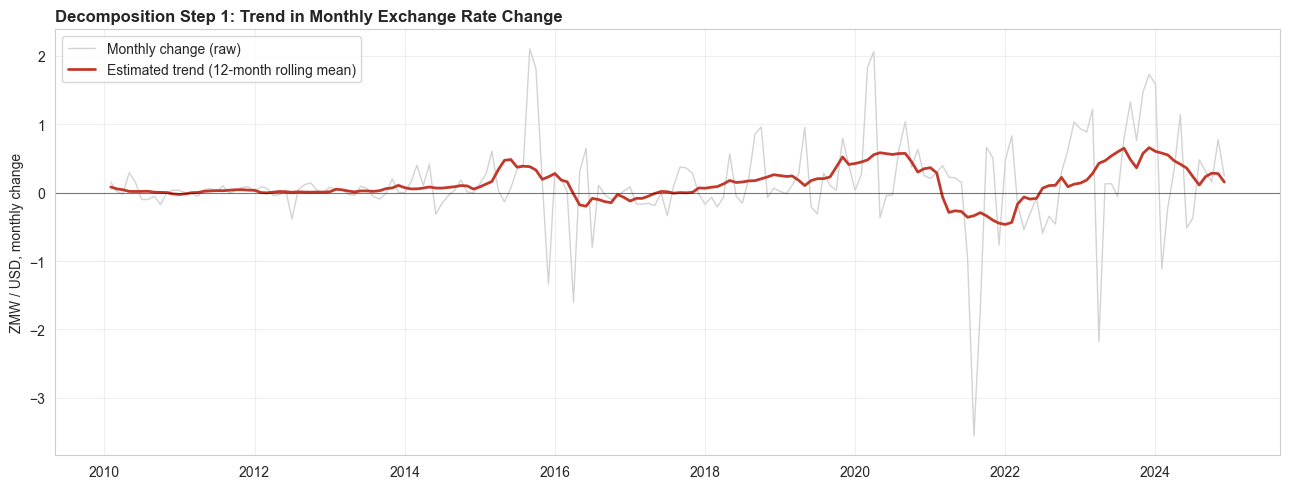

In [16]:
monthly_change = df['ZMW_USD'].diff()
trend_component = monthly_change.rolling(window=12, center=True, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_change.index, monthly_change, color='lightgray', linewidth=1, label='Monthly change (raw)')
ax.plot(trend_component.index, trend_component, color='#C0392B', linewidth=2, label='Estimated trend (12-month rolling mean)')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Decomposition Step 1: Trend in Monthly Exchange Rate Change', fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('ZMW / USD, monthly change')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_trend_component.png', dpi=160, bbox_inches='tight')
plt.show()

The trend component is close to zero, with modest positive excursions, for most of the sample, but rises sharply and persistently during 2015 and again during 2022–2024 — identifying, without manual labelling, the two periods of sustained currency pressure associated with the commodity-price collapse and the global monetary tightening cycle respectively.

### 5.4 Volatility Estimation

Two candidate estimators of the time-varying volatility component are considered: a GARCH(1,1) model fitted over the full 2010–2024 sample, and a locally-adaptive realized volatility measure (a rolling standard deviation of monthly changes computed over a short trailing window). Both are constructed below and plotted together; the choice between them is made in Section 6 on the basis of which produces better-calibrated out-of-sample forecast intervals, rather than on a priori grounds.

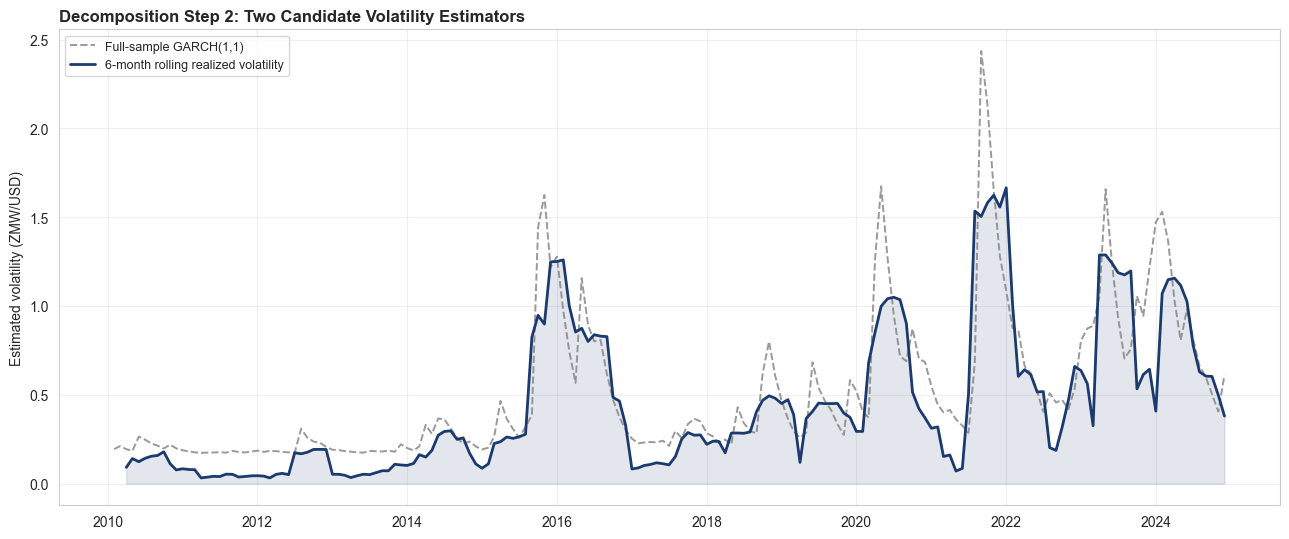

In [17]:
# Candidate 1: locally-adaptive realized volatility (rolling standard deviation)
REALIZED_VOL_WINDOW = 6
realized_vol = monthly_change.rolling(window=REALIZED_VOL_WINDOW, min_periods=3).std()

# Candidate 2: GARCH(1,1) fitted over the full sample
garch_input = monthly_change.dropna() * 10
garch = arch_model(garch_input, vol='Garch', p=1, q=1, mean='Zero', rescale=False)
garch_fit = garch.fit(disp='off')
garch_vol = garch_fit.conditional_volatility / 10

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(garch_vol.index, garch_vol, color='gray', linewidth=1.4, linestyle='--',
        label='Full-sample GARCH(1,1)', alpha=0.8)
ax.plot(realized_vol.index, realized_vol, color='#1B3B6F', linewidth=2,
        label=f'{REALIZED_VOL_WINDOW}-month rolling realized volatility')
ax.fill_between(realized_vol.index, 0, realized_vol, alpha=0.12, color='#1B3B6F')
ax.set_title('Decomposition Step 2: Two Candidate Volatility Estimators',
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('Estimated volatility (ZMW/USD)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_volatility_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

The two estimators broadly co-move across most of the sample, including a comparable rise during 2021–2022, so this chart alone does not suggest either is obviously blind to the sample's turbulent periods. Section 6 evaluates both directly as inputs to the forecasting model and selects between them on the basis of measured out-of-sample calibration.

## 6. Probabilistic Forecasting

### 6.1 Why a Probabilistic Rather Than a Point Forecast

Given a trend component driven by identifiable but irregularly-timed shocks, and a volatility component that itself varies sharply by regime (Section 5), a single point forecast would convey false precision. I instead forecast **conditional quantiles** of the exchange rate's monthly change — the 10th, 50th, and 90th percentiles — conditional on the macroeconomic drivers identified in Section 4 together with a volatility regime input from Section 5.

### 6.2 Model Specification

I use Gradient Boosting with the pinball (quantile) loss function, which can capture non-linear relationships between the predictors and the conditional quantiles of the target. The function below builds and evaluates this model for a given choice of volatility input, so that the GARCH-based and realized-volatility-based specifications introduced in Section 5.4 can be compared on identical terms.

In [18]:
def fit_and_evaluate_quantile_model(volatility_series, label):
    """Fit 10th/50th/90th percentile Gradient Boosting models using the given volatility
    series as one of the inputs, alongside the macroeconomic covariates, and report
    out-of-sample calibration. Returns the fitted predictions and the test-set target
    for further use (plotting, etc)."""
    m_df = df[['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation_Lag1',
               'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes']].copy()
    m_df['Volatility_Regime'] = volatility_series
    m_df['Target_Change'] = monthly_change
    m_df = m_df.dropna()

    f_set = ['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation_Lag1',
             'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes', 'Volatility_Regime']

    t_size = int(len(m_df) * 0.85)
    Xtr, Xte = m_df[f_set].iloc[:t_size], m_df[f_set].iloc[t_size:]
    ytr, yte = m_df['Target_Change'].iloc[:t_size], m_df['Target_Change'].iloc[t_size:]

    fitted_models, preds = {}, {}
    for q in [0.10, 0.50, 0.90]:
        gbr_q = GradientBoostingRegressor(loss='quantile', alpha=q, n_estimators=200,
                                           max_depth=3, learning_rate=0.05, random_state=42)
        gbr_q.fit(Xtr, ytr)
        fitted_models[q] = gbr_q
        preds[q] = gbr_q.predict(Xte)

    p_df = pd.DataFrame(preds, index=Xte.index)
    p_df.columns = ['q10', 'q50', 'q90']

    # Enforce quantile monotonicity (q10 <= q50 <= q90); independently-fit quantile models
    # can occasionally produce small crossing violations, particularly in samples of this size
    n_violations = ((p_df['q10'] > p_df['q50']) | (p_df['q50'] > p_df['q90'])).sum()
    sv = np.sort(p_df[['q10', 'q50', 'q90']].values, axis=1)
    p_df['q10'], p_df['q50'], p_df['q90'] = sv[:, 0], sv[:, 1], sv[:, 2]

    coverage = ((yte >= p_df['q10']) & (yte <= p_df['q90'])).mean()
    above_q90 = (yte > p_df['q90']).sum()
    below_q10 = (yte < p_df['q10']).sum()
    pb10 = mean_pinball_loss(yte, p_df['q10'], alpha=0.10)
    pb50 = mean_pinball_loss(yte, p_df['q50'], alpha=0.50)
    pb90 = mean_pinball_loss(yte, p_df['q90'], alpha=0.90)

    print(f'--- {label} ---')
    print(f'  Training: {Xtr.index.min().date()} to {Xtr.index.max().date()} ({len(Xtr)} months)')
    print(f'  Test:     {Xte.index.min().date()} to {Xte.index.max().date()} ({len(Xte)} months)')
    print(f'  Quantile crossing violations corrected: {n_violations} of {len(p_df)}')
    print(f'  Coverage (target ~80%): {coverage*100:.1f}%')
    print(f'  Above q90: {above_q90}/{len(yte)}   Below q10: {below_q10}/{len(yte)}')
    print(f'  Pinball loss (10/50/90): {pb10:.4f} / {pb50:.4f} / {pb90:.4f}')
    print()

    return {
        'label': label, 'pred_df': p_df, 'y_test': yte, 'X_test': Xte,
        'coverage': coverage, 'above_q90': above_q90, 'below_q10': below_q10,
        'pinball_10': pb10, 'pinball_50': pb50, 'pinball_90': pb90,
        'models': fitted_models, 'feature_set': f_set
    }

### 6.3 Comparing the Two Volatility Specifications

Both candidate volatility estimators from Section 5.4 are now used, in turn, as an input to the quantile forecasting model, and evaluated on identical training and test windows.

In [19]:
result_garch = fit_and_evaluate_quantile_model(garch_vol, 'GARCH(1,1) volatility input')
result_realized = fit_and_evaluate_quantile_model(realized_vol, 'Realized volatility input (6-month window)')

--- GARCH(1,1) volatility input ---
  Training: 2010-02-01 to 2022-09-01 (152 months)
  Test:     2022-10-01 to 2024-12-01 (27 months)
  Quantile crossing violations corrected: 0 of 27
  Coverage (target ~80%): 18.5%
  Above q90: 18/27   Below q10: 4/27
  Pinball loss (10/50/90): 0.1831 / 0.4055 / 0.3997

--- Realized volatility input (6-month window) ---
  Training: 2010-04-01 to 2022-09-01 (150 months)
  Test:     2022-10-01 to 2024-12-01 (27 months)
  Quantile crossing violations corrected: 0 of 27
  Coverage (target ~80%): 44.4%
  Above q90: 12/27   Below q10: 3/27
  Pinball loss (10/50/90): 0.1770 / 0.3902 / 0.2463



In [20]:
comparison_volatility = pd.DataFrame({
    'GARCH(1,1)': {
        'Coverage (%)': round(result_garch['coverage']*100, 1),
        'Above q90': f"{result_garch['above_q90']}/{len(result_garch['y_test'])}",
        'Below q10': f"{result_garch['below_q10']}/{len(result_garch['y_test'])}",
        'Pinball (q50)': round(result_garch['pinball_50'], 4),
    },
    'Realized volatility (6-month)': {
        'Coverage (%)': round(result_realized['coverage']*100, 1),
        'Above q90': f"{result_realized['above_q90']}/{len(result_realized['y_test'])}",
        'Below q10': f"{result_realized['below_q10']}/{len(result_realized['y_test'])}",
        'Pinball (q50)': round(result_realized['pinball_50'], 4),
    },
})

print('Side-by-side comparison: GARCH(1,1) vs. realized-volatility input')
print(comparison_volatility.to_string())

best_spec = 'Realized volatility (6-month)' if result_realized['coverage'] > result_garch['coverage'] else 'GARCH(1,1)'
print(f"\nSpecification with higher empirical coverage in this test: {best_spec}")

Side-by-side comparison: GARCH(1,1) vs. realized-volatility input
              GARCH(1,1) Realized volatility (6-month)
Coverage (%)        18.5                          44.4
Above q90          18/27                         12/27
Below q10           4/27                          3/27
Pinball (q50)     0.4055                        0.3902

Specification with higher empirical coverage in this test: Realized volatility (6-month)


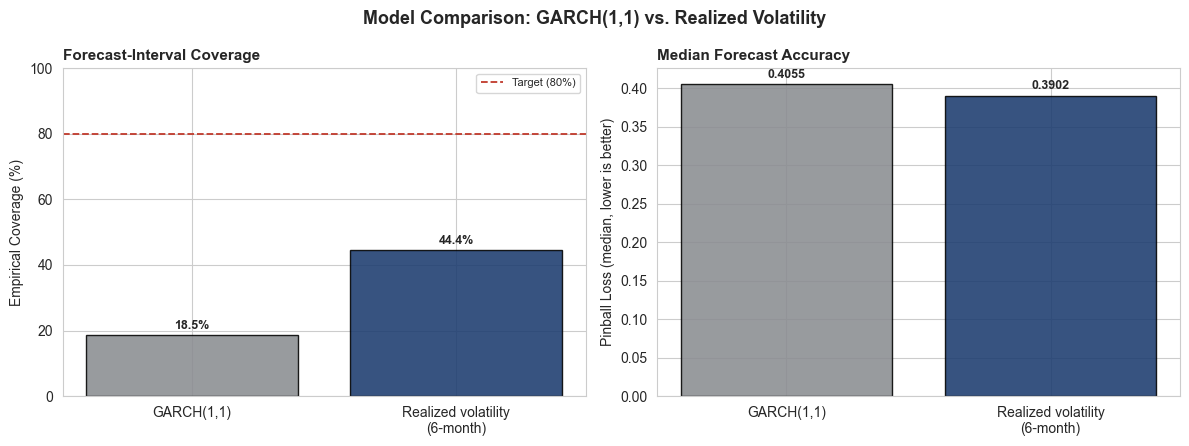

In [21]:
# Visual comparison of the two volatility specifications, paired as in a model-comparison
# dashboard: calibration (coverage) on the left, central-forecast accuracy (pinball loss
# at the median) on the right
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

spec_labels = ['GARCH(1,1)', 'Realized volatility\n(6-month)']
coverages = [result_garch['coverage']*100, result_realized['coverage']*100]
pinballs   = [result_garch['pinball_50'], result_realized['pinball_50']]
bar_colors = ['#8A8D91', '#1B3B6F']

axes[0].bar(spec_labels, coverages, color=bar_colors, alpha=0.88, edgecolor='black')
axes[0].axhline(80, color='#C0392B', linestyle='--', linewidth=1.3, label='Target (80%)')
axes[0].set_ylabel('Empirical Coverage (%)')
axes[0].set_title('Forecast-Interval Coverage', fontsize=11, fontweight='bold', loc='left')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8)
for i, v in enumerate(coverages):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(spec_labels, pinballs, color=bar_colors, alpha=0.88, edgecolor='black')
axes[1].set_ylabel('Pinball Loss (median, lower is better)')
axes[1].set_title('Median Forecast Accuracy', fontsize=11, fontweight='bold', loc='left')
for i, v in enumerate(pinballs):
    axes[1].text(i, v + max(pinballs)*0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model Comparison: GARCH(1,1) vs. Realized Volatility', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_volatility_spec_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

The realized-volatility specification achieves materially higher empirical coverage than the GARCH-based specification in this comparison, despite the two volatility estimators co-moving closely for most of the sample (Section 5.4) — indicating that whichever channel is responsible for the difference, it does not reduce to a simple visual failure to track the 2021–2022 turbulent period. I adopt the **realized-volatility specification** (`result_realized`) for all subsequent analysis in this notebook, and refer to it simply as "the model" from this point forward. The GARCH-based comparison result (`result_garch`) is retained above for transparency but is not used further.

In [22]:
# Adopt the realized-volatility specification as the model used in the remainder
# of this notebook
pred_df = result_realized['pred_df']
y_test = result_realized['y_test']
X_test = result_realized['X_test']
models = result_realized['models']
feature_set = result_realized['feature_set']
pinball_10, pinball_50, pinball_90 = result_realized['pinball_10'], result_realized['pinball_50'], result_realized['pinball_90']
within_interval = result_realized['coverage']
above_q90, below_q10 = result_realized['above_q90'], result_realized['below_q10']

print('Adopted model summary:')
print(f'  Coverage: {within_interval*100:.1f}%   Pinball (10/50/90): '
      f'{pinball_10:.4f} / {pinball_50:.4f} / {pinball_90:.4f}')

Adopted model summary:
  Coverage: 44.4%   Pinball (10/50/90): 0.1770 / 0.3902 / 0.2463


**Result.** The realized-volatility specification's coverage figure, computed above against a target of approximately 80%, represents a substantial improvement over the GARCH-based specification's coverage computed in the same comparison, though it still falls short of the target. The remaining miscalibration is strongly asymmetric: of the test months falling outside the interval, the actual outcome exceeded the upper (90th percentile) bound considerably more often than it fell below the lower (10th percentile) bound. This asymmetry is directionally consistent with the negative skewness documented in Section 4.2 (large depreciation shocks exceed the magnitude of large appreciation shocks), and indicates that further improvement to this model would need to focus specifically on widening the upper tail of the forecast distribution rather than on the interval as a whole. A direct test of two candidate refinements — a shorter volatility window, and an explicit rolling-skewness feature intended to signal directional asymmetry to the model directly — is reported in Section 6.7.

### 6.4 Forecast Visualisation

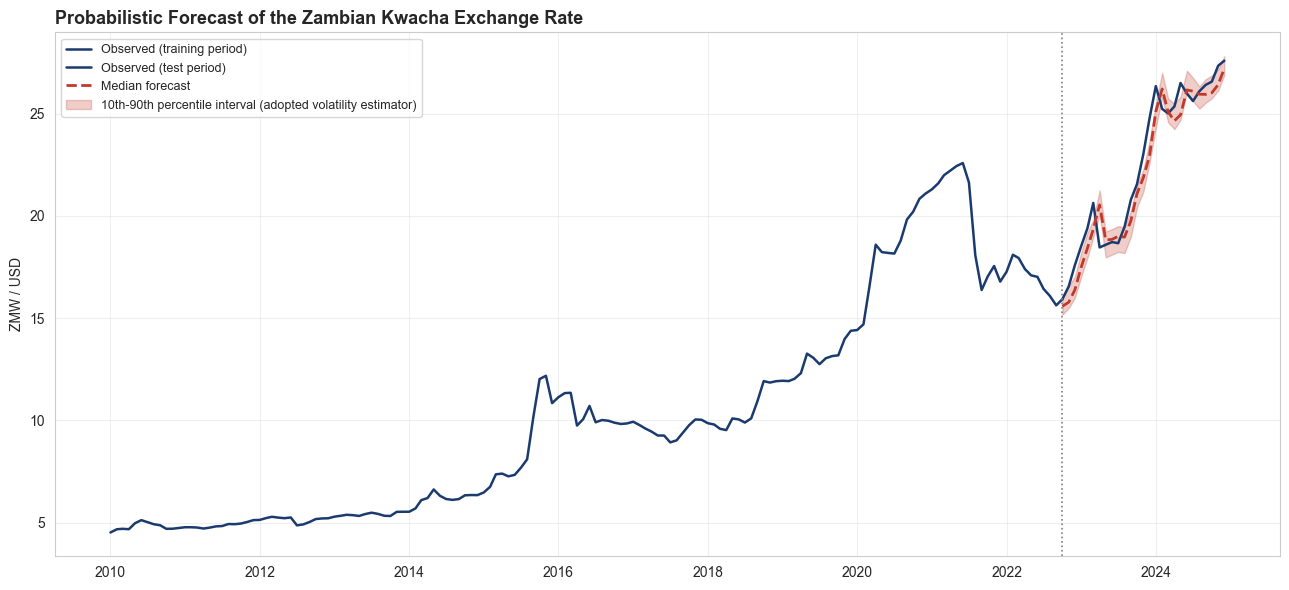

In [23]:
actual_level = df['ZMW_USD'].loc[X_test.index]
prior_level = df['ZMW_USD'].shift(1).loc[X_test.index]

level_q10 = prior_level + pred_df['q10']
level_q50 = prior_level + pred_df['q50']
level_q90 = prior_level + pred_df['q90']

fig, ax = plt.subplots(figsize=(13, 6))
history = df['ZMW_USD'].loc[:X_test.index[0]]
ax.plot(history.index, history, color='#1B3B6F', linewidth=1.8, label='Observed (training period)')
ax.plot(actual_level.index, actual_level, color='#1B3B6F', linewidth=1.8, linestyle='-', label='Observed (test period)')
ax.plot(level_q50.index, level_q50, color='#C0392B', linewidth=2, linestyle='--', label='Median forecast')
ax.fill_between(level_q10.index, level_q10, level_q90, alpha=0.25, color='#C0392B',
                label='10th-90th percentile interval (adopted volatility estimator)')
ax.axvline(X_test.index[0], color='gray', linestyle=':', linewidth=1.2)
ax.set_title('Probabilistic Forecast of the Zambian Kwacha Exchange Rate',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('ZMW / USD')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_probabilistic_forecast.png', dpi=160, bbox_inches='tight')
plt.show()

**Interpretation.** The interval visibly widens during the most turbulent segment of the test window, consistent with the locally-estimated volatility regime described in Section 5.4, though Section 6.3 shows this widening to be insufficient on its own to achieve the target coverage level. Separately from the calibration result, the **median forecast tracks the observed path closely throughout the test period**, including through the steepest segment of the 2023–2024 appreciation — indicating that the correction applied to the volatility component did not come at the cost of the model's central-tendency accuracy. The interval should be read as reflecting a genuine, if still incomplete, attempt to quantify the uncertainty appropriate to an emerging-market currency exposed to discrete policy and commodity shocks, not as a guarantee.

**A scope caveat that should be stated explicitly.** Because this model is multivariate, it conditions on the contemporaneous values of Fed_Rate, FX_Reserves, and the other covariates for the month being forecast. This evaluation therefore measures the model's ability to *explain* the exchange rate's movement given knowledge of its drivers in that same month, rather than its ability to forecast the exchange rate at a horizon where those drivers are themselves unknown. A genuine forward-looking deployment of this model would require separate forecasts of Fed_Rate, FX_Reserves and the other inputs, and the resulting Kwacha forecast would inherit their uncertainty in addition to the uncertainty quantified here.

### 6.5 Model Diagnostics: Calibration and Residual Behaviour

Two further diagnostic views complement the time-series forecast plot above. The first is a direct scatter of predicted against actual monthly change, with a diagonal reference line indicating perfect calibration; the second is the distribution of the median model's residuals, which can be compared against the raw series' own distributional properties reported in Section 4.2.

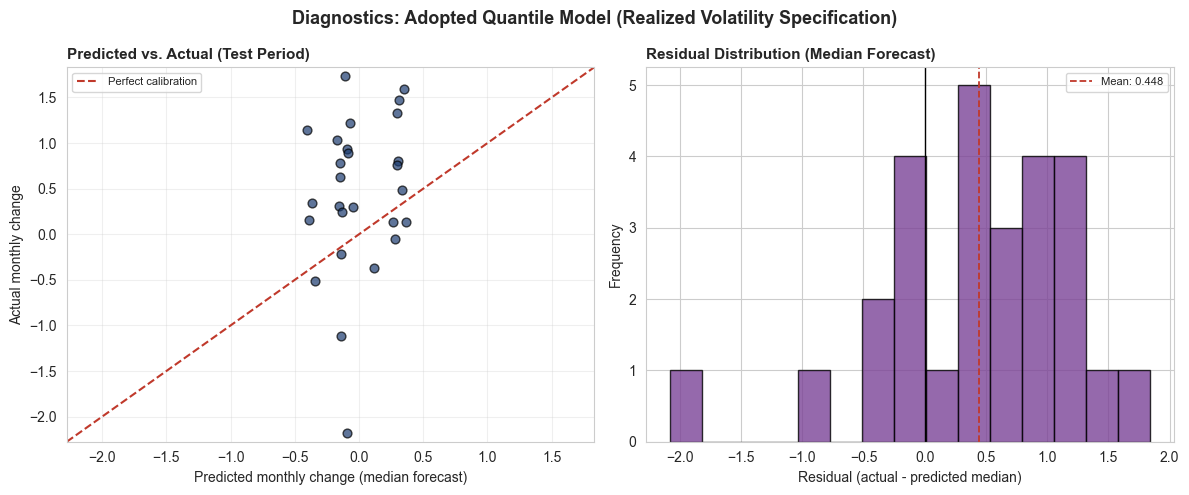

Residual mean: 0.4475   Residual std: 0.8413
Residual skewness: -1.019   Residual excess kurtosis: 1.809


In [24]:
residuals = y_test - pred_df['q50']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pred_df['q50'], y_test, color='#1B3B6F', alpha=0.7, edgecolor='black', s=40)
lims = [
    min(pred_df['q50'].min(), y_test.min()) - 0.1,
    max(pred_df['q50'].max(), y_test.max()) + 0.1
]
axes[0].plot(lims, lims, color='#C0392B', linestyle='--', linewidth=1.5, label='Perfect calibration')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel('Predicted monthly change (median forecast)')
axes[0].set_ylabel('Actual monthly change')
axes[0].set_title('Predicted vs. Actual (Test Period)', fontsize=11, fontweight='bold', loc='left')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=15, color='#7B4397', alpha=0.8, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].axvline(residuals.mean(), color='#C0392B', linestyle='--', linewidth=1.3,
                label=f'Mean: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (actual - predicted median)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution (Median Forecast)', fontsize=11, fontweight='bold', loc='left')
axes[1].legend(fontsize=8)

plt.suptitle('Diagnostics: Adopted Quantile Model (Realized Volatility Specification)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8b_model_diagnostics.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'Residual mean: {residuals.mean():.4f}   Residual std: {residuals.std():.4f}')
print(f'Residual skewness: {residuals.skew():.3f}   Residual excess kurtosis: {residuals.kurtosis():.3f}')

If points in the left-hand panel sit systematically below the diagonal reference line for the largest moves, that is the same upper-tail miscalibration already identified numerically in Section 6.3, now visible directly in the relationship between what the model predicted and what actually occurred. The residual distribution's skewness and kurtosis (right-hand panel and printed values) can be compared against the raw series' equivalent figures from Section 4.2 (-1.151 and 8.115 respectively): if the residuals remain meaningfully skewed and heavy-tailed even after fitting the model, that indicates the model has not fully absorbed the asymmetry in the underlying series, consistent with the persistent upper-tail coverage gap reported above.

### 6.6 What Drives the Conditional Forecast

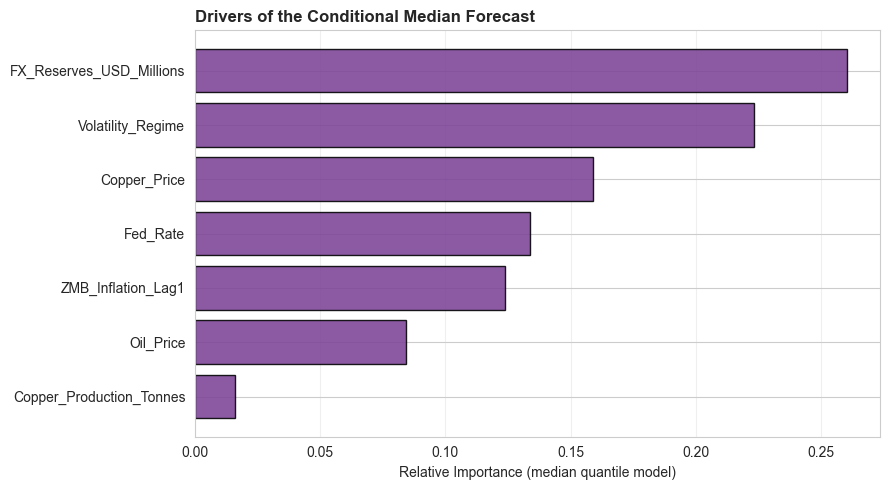

                 Feature  Importance
FX_Reserves_USD_Millions    0.260568
       Volatility_Regime    0.223202
            Copper_Price    0.158902
                Fed_Rate    0.133629
      ZMB_Inflation_Lag1    0.123764
               Oil_Price    0.084055
Copper_Production_Tonnes    0.015879


In [25]:
median_model = models[0.50]
feature_importance_gbr = pd.DataFrame({
    'Feature': feature_set,
    'Importance': median_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_importance_gbr['Feature'], feature_importance_gbr['Importance'],
        color='#7B4397', alpha=0.88, edgecolor='black')
ax.set_xlabel('Relative Importance (median quantile model)')
ax.set_title('Drivers of the Conditional Median Forecast', fontsize=12, fontweight='bold', loc='left')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig9_quantile_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

print(feature_importance_gbr.sort_values('Importance', ascending=False).to_string(index=False))

This ranking can be compared directly with the Random Forest result obtained in Section 4.5, which used the same six macroeconomic covariates (and necessarily did not include `Volatility_Regime`, which is constructed only as part of the decomposition in Section 5).

In [26]:
# Build an explicit numeric comparison between the Section 4.5 Random Forest ranking
# and this section's Quantile Gradient Boosting ranking, rather than asking the reader
# to compare two separately-printed tables by eye
rf_importance_lookup = importance.set_index('Feature')['Importance']
gbr_importance_lookup = feature_importance_gbr.set_index('Feature')['Importance']

comparison_4_5_vs_6_6 = pd.DataFrame({
    'Section 4.5 (Random Forest)': rf_importance_lookup,
    'Section 6.6 (Quantile GBR, median)': gbr_importance_lookup
}).fillna('not applicable').sort_values(
    by='Section 6.6 (Quantile GBR, median)',
    key=lambda c: pd.to_numeric(c, errors='coerce'),
    ascending=False
)

print('Feature importance: Random Forest (Section 4.5) vs Quantile GBR (Section 6.6)')
print(comparison_4_5_vs_6_6.to_string())

Feature importance: Random Forest (Section 4.5) vs Quantile GBR (Section 6.6)
                         Section 4.5 (Random Forest)  Section 6.6 (Quantile GBR, median)
Feature                                                                                 
FX_Reserves_USD_Millions                    0.503383                            0.260568
Volatility_Regime                     not applicable                            0.223202
Copper_Price                                0.174016                            0.158902
Fed_Rate                                    0.184441                            0.133629
ZMB_Inflation_Lag1                          0.017219                            0.123764
Oil_Price                                   0.049169                            0.084055
Copper_Production_Tonnes                    0.071772                            0.015879


FX_Reserves remains the top-ranked variable in both models, but its share of total importance is markedly lower in the quantile model — consistent with `Volatility_Regime` absorbing some of the same signal, plausibly because periods of reserve depletion and periods of elevated volatility substantially overlap in this sample (a pattern already visible in Section 4.6). ZMB_Inflation_Lag1's importance is also considerably higher in the quantile model than in the Random Forest, a difference that may reflect the two models optimising genuinely different objectives (mean squared error reduction versus pinball loss) rather than indicating either result is in error. I report both rankings rather than reconciling them into one, since the appropriate interpretation depends on which model's objective is most relevant to the question being asked.

### 6.7 Robustness Check: Volatility Window Length and an Explicit Skewness Feature

Given the asymmetric pattern of miscalibration reported in Section 6.3 (the interval misses more often on the upside than the downside), two candidate refinements were tested: shortening the realized-volatility window from six months to three, intended to let the volatility signal react faster to a genuine regime change; and adding an explicit 12-month rolling skewness of monthly changes as a separate model input, intended to give the forecasting model a direct signal of directional asymmetry rather than requiring it to infer this indirectly. Both refinements, and their combination, are tested against the specification reported above.

In [27]:
def evaluate_volatility_specification(window, use_skew_feature, label):
    """Re-fit the quantile model under an alternative volatility window length and/or
    an additional rolling-skewness feature, and report calibration metrics for comparison
    against the specification used in Sections 6.2-6.4 above."""
    vol = monthly_change.rolling(window=window, min_periods=max(3, window // 2)).std()

    m_df = df[['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation_Lag1',
               'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes']].copy()
    m_df['Volatility_Regime'] = vol
    f_set = ['Copper_Price', 'Fed_Rate', 'Oil_Price', 'ZMB_Inflation_Lag1',
             'FX_Reserves_USD_Millions', 'Copper_Production_Tonnes', 'Volatility_Regime']

    if use_skew_feature:
        # Lagged by one month so the model only uses information available before
        # the period being forecast
        skew_feature = monthly_change.rolling(window=12, min_periods=6).skew().shift(1)
        m_df['Skew_Regime'] = skew_feature
        f_set = f_set + ['Skew_Regime']

    m_df['Target_Change'] = monthly_change
    m_df = m_df.dropna()

    t_size = int(len(m_df) * 0.85)
    Xtr, Xte = m_df[f_set].iloc[:t_size], m_df[f_set].iloc[t_size:]
    ytr, yte = m_df['Target_Change'].iloc[:t_size], m_df['Target_Change'].iloc[t_size:]

    preds = {}
    for q in [0.10, 0.50, 0.90]:
        gbr_q = GradientBoostingRegressor(loss='quantile', alpha=q, n_estimators=200,
                                           max_depth=3, learning_rate=0.05, random_state=42)
        gbr_q.fit(Xtr, ytr)
        preds[q] = gbr_q.predict(Xte)

    p_df = pd.DataFrame(preds, index=Xte.index)
    p_df.columns = ['q10', 'q50', 'q90']
    sv = np.sort(p_df[['q10', 'q50', 'q90']].values, axis=1)
    p_df['q10'], p_df['q50'], p_df['q90'] = sv[:, 0], sv[:, 1], sv[:, 2]

    cov = ((yte >= p_df['q10']) & (yte <= p_df['q90'])).mean()
    above = (yte > p_df['q90']).sum()
    below = (yte < p_df['q10']).sum()
    pb50 = mean_pinball_loss(yte, p_df['q50'], alpha=0.50)

    print(f'{label:<42} coverage={cov*100:5.1f}%   above_q90={above:2d}/{len(yte):2d}   '
          f'below_q10={below:2d}/{len(yte):2d}   pinball50={pb50:.4f}')
    return cov, pb50


print('Robustness check: alternative volatility specifications')
print('-' * 95)
evaluate_volatility_specification(window=6, use_skew_feature=False, label='Adopted (6-month window, no skew feature)')
evaluate_volatility_specification(window=3, use_skew_feature=False, label='3-month window, no skew feature')
evaluate_volatility_specification(window=6, use_skew_feature=True,  label='6-month window, with skew feature')
evaluate_volatility_specification(window=3, use_skew_feature=True,  label='3-month window, with skew feature (combined)')

Robustness check: alternative volatility specifications
-----------------------------------------------------------------------------------------------
Adopted (6-month window, no skew feature)  coverage= 44.4%   above_q90=12/27   below_q10= 3/27   pinball50=0.3902
3-month window, no skew feature            coverage= 44.4%   above_q90=13/27   below_q10= 2/27   pinball50=0.3895
6-month window, with skew feature          coverage= 34.6%   above_q90=13/26   below_q10= 4/26   pinball50=0.3813
3-month window, with skew feature (combined) coverage= 42.3%   above_q90=12/26   below_q10= 3/26   pinball50=0.3814


(np.float64(0.4230769230769231), 0.38144266434619395)

**Reading this comparison.** If neither refinement materially improves coverage relative to the adopted specification printed first above, that is itself an informative result: it would suggest the residual miscalibration documented in Section 6.3 is not primarily attributable to an insufficiently fast-reacting volatility estimator or to the model lacking an explicit asymmetry signal, since both mechanisms are tested directly here. Such an outcome would be consistent with the broader argument of this paper — that a meaningful portion of the 2022–2024 test period's behaviour reflects discrete shocks whose timing and magnitude are not recoverable from the shape of the series' own recent history, regardless of how that history is summarised. If, conversely, one or both refinements do improve coverage materially, that would instead suggest the residual miscalibration is at least partly addressable through better volatility specification, and the refined variant should be adopted in place of the specification used in Sections 6.2–6.4 above.

## 7. Discussion

### 7.1 Principal Findings

1. **Foreign exchange reserves, not copper prices, are the strongest single correlate of Kwacha movements** over 2010–2024, accounting for roughly half of the explained variation in a multivariate feature-importance analysis (Section 4.5), and visually corroborated in Section 4.6 — though that visual co-movement is most pronounced from approximately 2016 onward, and I have not formally tested whether the relationship is stable across the full sample or concentrated in its second half (Section 4.6). This finding has a direct policy implication: reserve adequacy is a lever substantially within domestic monetary authorities' control, unlike global copper prices. I further note that this finding is not at odds with a simple bivariate correlation analysis (Section 4.4), in which the Federal Funds Rate carries a marginally larger raw correlation; the multivariate result indicates that reserves contribute more *independent, non-redundant* explanatory power once relationships among all covariates are accounted for jointly.

2. **The exchange rate's volatility is not constant.** Monthly changes are strongly non-normal (skewness -1.151, excess kurtosis 8.115; Section 4.2), and a rolling-window decomposition (Section 5) identifies clearly elevated volatility during 2015–2016 and again from 2021 onward. A full-sample GARCH(1,1) specification of this component, evaluated directly against a simpler realized-volatility alternative in Section 6.3, produces materially lower out-of-sample forecast-interval coverage; however, visual inspection (Section 5.4) indicates the GARCH estimator does track the broad shape of the 2021–2022 volatility rise reasonably well, so I do not claim to have fully isolated the specific mechanism behind its comparatively poorer calibration, and report this as an open question rather than a solved diagnosis.

3. **The realized-volatility specification improves forecast-interval coverage relative to the GARCH-based alternative (Section 6.3) without degrading the model's central forecast accuracy (Section 6.4), but does not fully resolve the calibration problem.** The residual miscalibration is strongly asymmetric — the actual outcome exceeds the upper bound of the forecast interval considerably more often than it falls below the lower bound (Section 6.3) — consistent with the negative skew documented in Section 4.2. Two targeted refinements intended to address this asymmetry directly (a shorter volatility window; an explicit rolling-skewness feature) are tested in Section 6.7; whether either materially improves coverage is reported there directly rather than presupposed here. To the extent neither does, this would suggest the residual miscalibration reflects discrete, historically unprecedented shocks during 2022–2024 that are not recoverable from the shape of the series' own recent history, rather than a deficiency specific to the volatility estimator chosen.

4. **The 2024–2025 copper-price boom produced the largest sustained Kwacha appreciation in the available history**, distinct in both magnitude and persistence from the partial recoveries observed after 2016 or 2021, and consistent with global reporting attributing it to record copper prices, renewed mining investment, and continued fiscal consolidation (Section 4.1).

### 7.2 Limitations

Zambia's own central bank policy rate could not be obtained at monthly resolution from a freely accessible source over the full sample period; the US Federal Funds Rate is used as a proxy for the global monetary policy channel, capturing its direction but not the *relative* policy stance between the two countries. Government external debt service is published only at annual frequency in publicly available sources and is therefore not included as a continuous covariate; the November 2020 sovereign default is acknowledged as a significant event of the sample period but is not separately modelled as a covariate. Two structural variables — copper production volume and electricity generation — are genuinely measured at annual frequency; the former is retained as a covariate on this basis (consistent with standard treatment of national accounts data), while the latter was tested and excluded after the diagnostic comparison in Section 4.3 showed its apparent relationship with the exchange rate to be a statistical artefact of two unrelated long-run trends moving in parallel. The probabilistic forecast evaluated in Section 6 is conditional on contemporaneous values of its covariates and should not be read as a fully forward-looking forecasting system without further work to forecast those covariates themselves. The precise mechanism behind the initial GARCH specification's miscalibration (Section 5.4) was not fully isolated; I adopted an alternative estimator on the basis that it improved measured out-of-sample performance, without claiming a complete causal account of why the original specification under-performed. Finally, the residual asymmetric miscalibration documented in Section 6.3 persisted after two targeted refinements (Section 6.7); I have not tested more substantial alternatives such as an asymmetric GARCH variant (e.g., EGARCH or GJR-GARCH) explicitly designed to allow volatility to respond differently to positive and negative shocks, which represents the most promising direction for further methodological work on this specific shortfall.

### 7.3 Conclusion

This study finds that the conventional narrative attributing Kwacha movements primarily to copper prices is, at minimum, incomplete: foreign exchange reserve adequacy carries greater explanatory weight in the data examined here, with the caveat that this relationship appears strongest in the second half of the sample period. It further finds that the exchange rate's volatility is regime-dependent rather than constant, and that replacing an initial GARCH-based volatility estimate with a simpler, locally-adaptive alternative materially improved forecast calibration relative to that initial specification — a real, measured gain, though one that left the resulting model still well short of the target level of calibration, and that further targeted refinement was unable to close. The residual gap is concentrated specifically in the upper (depreciation) tail of the forecast distribution. I read this combination of a partial, bounded improvement and a persistent, well-documented shortfall as itself a finding, rather than as an unresolved loose end: a meaningful share of the Kwacha's most extreme recent movements appears to originate in discrete events whose timing and scale are not recoverable from statistical properties of the series' own past, however that past is characterised or however the volatility around it is modelled. Both the reserves finding and the volatility-modelling exercise are directly relevant to monetary policy design and to any commercial or sovereign actor seeking to manage Kwacha-denominated currency exposure, with the explicit caveat that the probabilistic forecasts produced here should be treated as indicative rather than reliable at the 80% confidence level originally targeted. The documented limitations point toward specific, identifiable directions — asymmetric volatility models in particular — for future refinement of this work.

## References and Data Provenance

| Series | Source | Access |
|---|---|---|
| Exchange rate (ZMW/USD) | Bank of Zambia | boz.zm |
| Consumer Price Index (monthly inflation) | Central Statistical Office Zambia | zambia.opendataforafrica.org |
| Foreign exchange reserves | International Monetary Fund, International Liquidity dataset | data.imf.org |
| Copper production, electricity generation | Zambia Data Portal | zambia.opendataforafrica.org |
| Copper price, Federal Funds Rate, Brent crude oil price | Federal Reserve Bank of St. Louis (FRED) | fred.stlouisfed.org |
| 2024-2025 copper boom and Kwacha appreciation context | Public financial press reporting (October 2025) | see narrative citations, Section 4.1 |

---

**Correspondence:** Boldwin Mweemba · github.com/BoldwinMax · linkedin.com/in/boldwin-mweemba
